# 04. cuPF CPU: 같은 Newton step에서 무엇을 바꾸는가

**목표**
- cuPF CPU path가 baseline Newton 구조에서 바꾸는 지점을 분리한다.
- 새 power-flow 수식을 푸는 것이 아니라 같은 `J dx = -F`를 다른 방식으로 조립하고 푼다는 점을 확인한다.

**비교 축**
- Linear solver: UMFPACK vs KLU
- Jacobian fill: pandapower-like formula vs native fixed-pattern fill
- Timing phase: `initialize_ms` vs `solve_ms`

**코드 위치의 의미**
- `cpu_umfpack.cpp`: Newton step의 UMFPACK linear solve backend
- `cpu_klu.cpp`: Newton step의 KLU linear solve backend
- fixed pattern Jacobian: 같은 sparse pattern을 반복해서 쓰는 전력조류 문제의 구조 활용


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False
pd.set_option('display.max_colwidth', 120)

TUTORIAL_CASE = tu.TUTORIAL_LARGE_CASE
RUN_BENCHMARKS = True
REPEATS = 1
WARMUP = 0


In [2]:
display(pd.DataFrame([
    {'variant': 'cupf-cpu-umfpack-pandapower-jac', 'meaning': 'pandapower-like Jacobian + UMFPACK linear solve'},
    {'variant': 'cupf-cpu-klu-pandapower-jac', 'meaning': 'same Jacobian formula, KLU linear solve'},
    {'variant': 'cupf-cpu-klu', 'meaning': 'native fixed-pattern Jacobian fill + KLU'},
]))
case = tu.load_case(TUTORIAL_CASE)
print(f"case={case.case_name}, buses={case.ybus.shape[0]}, ybus_nnz={case.ybus.nnz}")


,variant,meaning
0,cupf-cpu-umfpack-pandapower-jac,pandapower-like Jacobian + UMFPACK linear solve
1,cupf-cpu-klu-pandapower-jac,"same Jacobian formula, KLU linear solve"
2,cupf-cpu-klu,native fixed-pattern Jacobian fill + KLU


case=case6468rte, buses=6468, ybus_nnz=22598


**Build cell의 역할**
- 본문 결론은 build log가 아니라 결과 해석에 있다.
- 그래도 후임자가 같은 환경에서 다시 실행할 수 있도록 CPU evaluator를 준비한다.


In [3]:
build = tu.build_eval('cpu', jobs=2, timeout=2400)
print(tu.command_summary(build, tail_lines=16))


$ bash benchmark/scripts/build_eval.bash cpu --jobs 2
[OK] elapsed=0.2s
-- spdlog not found: disabling cuPF logging
-- Found pybind11: /usr/local/include (found version "3.0.1")
-- Configuring done
-- Generating done
-- Build files have been written to: /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval] build _cupf + cupf_cpp_evaluate (-j 2)
Consolidate compiler generated dependencies of target cupf
[ 87%] Built target cupf
Consolidate compiler generated dependencies of target _cupf
[100%] Built target _cupf
[ 82%] Built target cupf
Consolidate compiler generated dependencies of target cupf_cpp_evaluate
[100%] Built target cupf_cpp_evaluate
[build_eval] done. artifacts under /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/tests/cupf_cpp_evaluate
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/_cupf.cpython-310-x86_64-linux-gnu.so


**비교 순서**
1. `pandapower-like Jacobian + UMFPACK`
2. `pandapower-like Jacobian + KLU`
3. `native fixed-pattern Jacobian + KLU`

**읽는 법**
- 1 -> 2: linear solver 교체 효과
- 2 -> 3: Jacobian fill/pattern 재사용 효과


$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-cpu-20260601-140502 --cases case6468rte --repeats 1 --warmup 0 --variants cupf-cpu-umfpack-pandapower-jac-pybind cupf-cpu-klu-pandapower-jac-pybind cupf-cpu-klu-pybind
[OK] elapsed=11.4s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_cupf_pybind --dataset-root /datasets/matpower --run-name tutorial-cpu-20260601-140502 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 0 --repeats 1 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte --variants cupf-cpu-klu-pandapower-jac-pybind cupf-cpu-klu-pybind cupf-cpu-umfpack-pandapower-jac-pybind
[cupf-cpu-klu-pybind][OK] case6468rte repeat=0 init_ms=7.775 solve_ms=12.220 iters=4 resid=1.341e-11
[cupf-cpu-klu-pybind] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-cpu-20260601-140502/cupf-cpu-

,variant,status,linear_solver,jacobian,initialize_ms,solve_ms,worst_residual,note
0,cupf-cpu-klu-pandapower-jac-pybind,ok,klu,pandapower,7.800000,12.161710,1.340572e-11,
1,cupf-cpu-klu-pybind,ok,klu,native,7.774943,12.219649,1.340572e-11,
2,cupf-cpu-umfpack-pandapower-jac-pybind,ok,umfpack,pandapower,9.414788,58.142800,1.015891e-11,


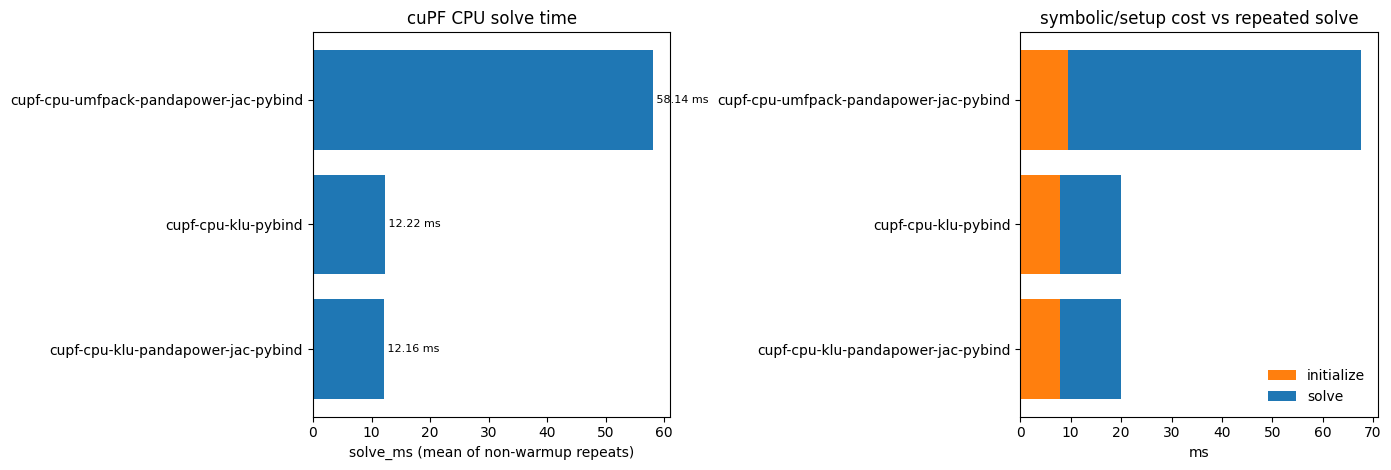

In [4]:
variants = [
    'cupf-cpu-umfpack-pandapower-jac-pybind',
    'cupf-cpu-klu-pandapower-jac-pybind',
    'cupf-cpu-klu-pybind',
]
if RUN_BENCHMARKS and build.ok:
    run_dir, command = tu.run_tutorial_benchmark(
        variants=variants,
        run_name=tu.timestamp_run_name('tutorial-cpu'),
        cases=[TUTORIAL_CASE],
        repeats=REPEATS,
        warmup=WARMUP,
        timeout=3600,
    )
    print(tu.command_summary(command, tail_lines=18))
else:
    run_dir = tu.tutorial_output_root()
    print('CPU benchmark was not run because the build did not complete or RUN_BENCHMARKS=False.')

summary = tu.benchmark_result_table(run_dir)
display(summary[['variant', 'status', 'linear_solver', 'jacobian', 'initialize_ms', 'solve_ms', 'worst_residual', 'note']])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
tu.plot_variant_timing(summary, axes[0], 'cuPF CPU solve time')
tu.plot_init_solve_stack(summary, axes[1], 'symbolic/setup cost vs repeated solve')
plt.tight_layout()


**비교 구조**
- `UMFPACK + pandapower-like Jacobian`
  - 비교 기준이다.
  - pandapower-like Jacobian 수식과 SuiteSparse 계열 direct solver를 함께 둔다.
- `KLU + pandapower-like Jacobian`
  - Jacobian 수식은 그대로 두고 linear solver만 바꾼다.
  - 현재 출력에서는 이 변경에서 가장 큰 solve time 차이가 보인다.
- `KLU + native fixed-pattern Jacobian`
  - linear solver를 KLU로 고정하고 Jacobian fill 방식을 바꾼다.
  - 현재 `case6468rte`의 aggregate `solve_ms`에서는 pandapower-like Jacobian과 큰 차이가 보이지 않는다.

**주의**
- 이 표만으로 `native fixed-pattern Jacobian 효과가 없다`고 결론 내리면 안 된다.
- 여기서 보이는 값은 pybind runner의 aggregate `solve_ms`다.
- Jacobian fill만의 효과를 분리하려면 native timer나 stage-level timer가 필요하다.


**CPU 결과 해석**
- `initialize_ms`: symbolic analysis와 solver setup이 주로 보이는 구간
- `solve_ms`: Newton 반복 안의 numeric factorization/solve와 update가 포함된 구간
- 이번 `case6468rte` 결과에서는 solver backend 교체 효과가 가장 크게 관찰된다.
- KLU를 고정한 뒤 native Jacobian과 pandapower-like Jacobian의 차이는 aggregate `solve_ms`에서 작게 보인다.
- 결론: 이 노트북은 `solver backend`와 `Jacobian fill`을 분리해 읽는 법을 보여준다. 세부 병목 비율은 stage-level timing으로 다시 봐야 한다.
